In [61]:
import torch
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import r2_score
import random
import matplotlib as mpl
import os
import gc
import pandas as pd
import csv
from numpy import *

from torch.utils.tensorboard import SummaryWriter
from datetime import date
# from generate_property import output_property

In [62]:
data = np.load('data.npy', allow_pickle=True)

# make dict of data with column 0 as key and column 1 as values
data_dict = {}
for i in range(len(data)):
    key = data[i][0]
    value = data[i][1]
    data_dict[key] = value
np.save('data_dict.npy', data_dict)

print(data_dict['GTCATGTT'])

0.7817733826124598


In [63]:
from generate_property import output_property_oracle
output_property_oracle = output_property_oracle()
prop = output_property_oracle.output_property(['GTCATGTT'])
print(prop)

[0.78177338]


In [64]:
## finding the largest protein
def find_max_len(data):
    max_len = 0
    for i in range(data.shape[0]):
        str_len = list(data[i,0])
        if max_len < len(str_len):
            max_len = len(str_len)
            # print(max_len)
    print('Max len is', max_len)
    return max_len

max_len = find_max_len(data)

Max len is 8


In [65]:
# # different amino acids
amino_acid = ['A', 'G','C','T'] # O is the uncommon amino acid, so total length is 21
# amino_acid = ['A', 'V', 'F', 'I', 'L','D','E','K','S','T','Y','C','N','Q', 'P','M', 'R', 'H', 'W', 'G','X'] # O is the uncommon amino acid, so total length is 21
print('Number of unique amino acids are', np.shape(np.unique(amino_acid))[0])
np.save('categorical_variables', amino_acid)
def onehotseq(sequence):
  aa_seq = ''
  seq_len = len(sequence)
  seq_en = np.zeros(( seq_len, np.shape(amino_acid)[0]))
  act_len = 0
  for i in range(seq_len):
    if sequence[i] in amino_acid:
      pos = amino_acid.index(sequence[i])
      seq_en[act_len,pos] = 1
      act_len += 1  
      aa_seq += sequence[i]    
    elif (sequence[i] not in amino_acid) and (sequence[i] != " ") and (sequence[i] != '\ufeff'):
      pos = amino_acid.index('X')
      seq_en[act_len,pos] = 1
      act_len += 1 
      aa_seq += sequence[i]
  return seq_en[0:act_len, :], aa_seq

Number of unique amino acids are 4


In [66]:
# max_len = find_max_len(data)
ohe = np.zeros((data.shape[0], max_len, len(amino_acid)))  ## batch size*sequenc_len*21
seq_string = np.zeros((data.shape[0],), dtype=object) ## it will store the string of amino acids
seq_lengths = np.zeros((data.shape[0],))
tm = np.zeros((data.shape[0], 1))

for i in range(ohe.shape[0]):
    seq_en, aa_seq = onehotseq(list(data[i,0]))
    seq_string[i,] = aa_seq
    ohe[i,0:seq_en.shape[0],:] =  seq_en
    seq_lengths[i,] = seq_en.shape[0]
    tm[i,0] = data[i,1]

# print(seq_string)
# np.save('./pure_b_factor_model/collagen_all_ohe', ohe)
# np.save('./pure_b_factor_model/collagen_all_seq_lengths', seq_lengths)
# np.save('./pure_b_factor_model/collagen_all_tm', tm)
output_y = tm
seq_length = seq_lengths

print(len(aa_seq), len(ohe))
print(seq_string[10])
print(ohe[10,5,:])
print(ohe[10,1,:])


# output_y = toy_prop

# idx_20 = (seq_length>20)
# seq_length = seq_length[idx_20]
# seq_string = seq_string[idx_20]
# output_y = output_y[idx_20]
# ohe = ohe[idx_20]

8 65792
AAAAAAGG
[1. 0. 0. 0.]
[1. 0. 0. 0.]


In [67]:
req_num = 50

all_ex = np.arange(ohe.shape[0])
X, x_test, _, _ = train_test_split( all_ex, all_ex, test_size=0.127,random_state=50) ## [10,50,70]
x_train, x_valid, _, _ = train_test_split( X, X, test_size=0.145,random_state=50)
_, x_train, _, _ = train_test_split( x_train, x_train, test_size=0.967,random_state=1000) ## [10,50,100]

x_train = x_train[:req_num]

print('Train',x_train.shape)
print('Test' ,x_test.shape)
print('Valid',x_valid.shape)

print(ohe[x_train].shape, seq_length[x_train].shape, output_y[x_train].shape)

Train (50,)
Test (8356,)
Valid (8329,)
(50, 8, 4) (50,) (50, 1)


In [68]:
np.save('./x_train', ohe[x_train])
np.save('./len_train', seq_length[x_train])
np.save('./y_train', output_y[x_train])
np.save('./seq_train', seq_string[x_train])

np.save('./x_valid', ohe[x_valid])
np.save('./len_valid', seq_length[x_valid])
np.save('./y_valid', output_y[x_valid])
np.save('./seq_valid', seq_string[x_valid])

np.save('./x_test', ohe[x_test])
np.save('./len_test', seq_length[x_test])
np.save('./y_test', output_y[x_test])
np.save('./seq_test', seq_string[x_test])

    
# np.save('./store_data/x_train'+str(trial), ohe[x_train])
# np.save('./store_data/len_train'+str(trial), seq_length[x_train])
# np.save('./store_data/y_train'+str(trial), output_y[x_train])

# np.save('./store_data/x_valid'+str(trial), ohe[x_valid])
# np.save('./store_data/len_valid'+str(trial), seq_length[x_valid])
# np.save('./store_data/y_valid'+str(trial), output_y[x_valid])

# np.save('./store_data/x_test'+str(trial), ohe[x_test])
# np.save('./store_data/len_test'+str(trial), seq_length[x_test])
# np.save('./store_data/y_test'+str(trial), output_y[x_test])

(array([    0.,     0.,     0.,     0.,     0., 65792.,     0.,     0.,
            0.,     0.]),
 array([7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5]),
 <BarContainer object of 10 artists>)

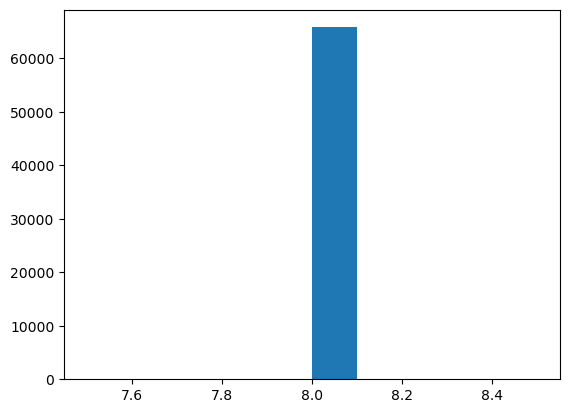

In [69]:
plt.hist(seq_length)

(array([  386.,  2594.,  6874., 10696., 12570., 12502., 10544.,  6718.,
         2570.,   338.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

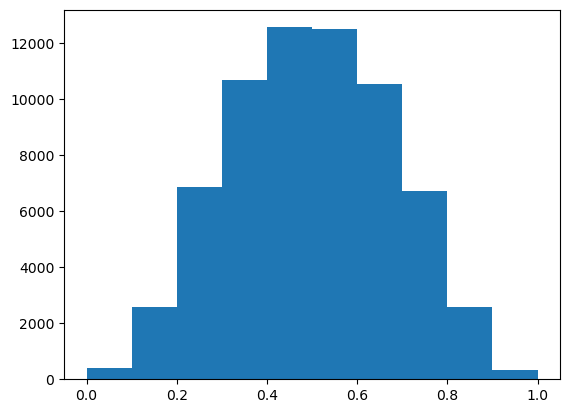

In [70]:
plt.hist(output_y)